In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [2]:
# Load dataset
data = pd.read_csv("/content/sales_data.csv")

# Display first rows
print(data.head())

         Date  Sales
0  2023-01-01    200
1  2023-01-02    210
2  2023-01-03    190
3  2023-01-04    220
4  2023-01-05    250


In [3]:
# Convert Date column to datetime
data['Date'] = pd.to_datetime(data['Date'])

# Create numeric index for regression
data['Day'] = np.arange(len(data))

print(data.head())

        Date  Sales  Day
0 2023-01-01    200    0
1 2023-01-02    210    1
2 2023-01-03    190    2
3 2023-01-04    220    3
4 2023-01-05    250    4


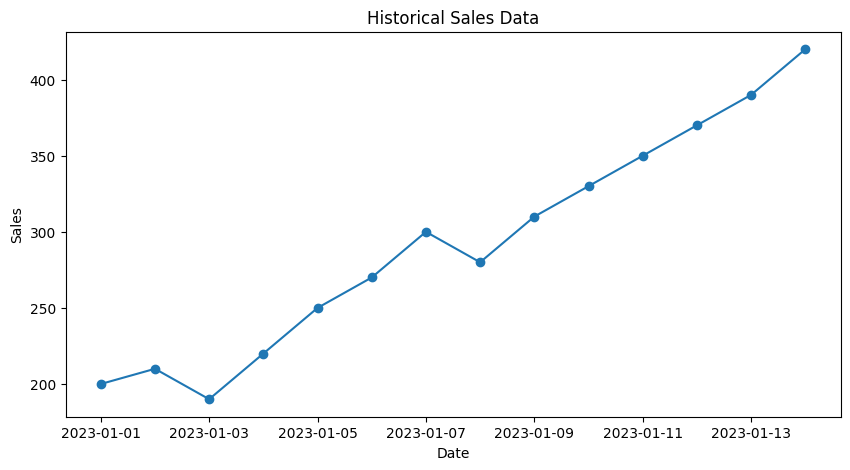

In [4]:
plt.figure(figsize=(10,5))
plt.plot(data['Date'], data['Sales'], marker='o')
plt.title("Historical Sales Data")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [6]:
X = data[['Day']]
y = data['Sales']

In [7]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [8]:
predictions = model.predict(X)

data['Predicted_Sales'] = predictions
print(data.head())

        Date  Sales  Day  Predicted_Sales
0 2023-01-01    200    0       179.714286
1 2023-01-02    210    1       197.010989
2 2023-01-03    190    2       214.307692
3 2023-01-04    220    3       231.604396
4 2023-01-05    250    4       248.901099


In [9]:
rmse = np.sqrt(mean_squared_error(y, predictions))
print("RMSE:", rmse)

RMSE: 13.019729021721542


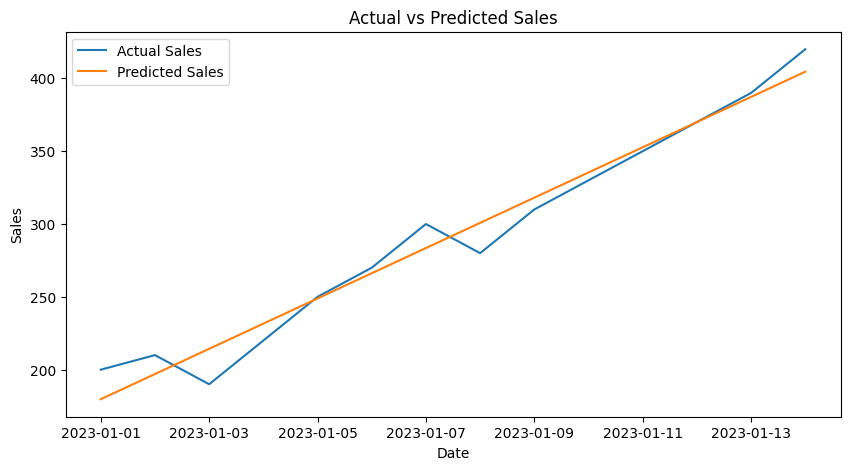

In [10]:
plt.figure(figsize=(10,5))

plt.plot(data['Date'], data['Sales'], label="Actual Sales")
plt.plot(data['Date'], data['Predicted_Sales'], label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

In [11]:
future_days = np.arange(len(data), len(data)+7).reshape(-1,1)
future_predictions = model.predict(future_days)

print("Future Sales Prediction:")
print(future_predictions)

Future Sales Prediction:
[421.86813187 439.16483516 456.46153846 473.75824176 491.05494505
 508.35164835 525.64835165]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
